# Vacuum, sterile, and reactor examples

This notebook reproduces the intent of four demos from `examples/`:

- `vacuum_2flavors.py`
- `faser_sterile.py`
- `sterile_raa_plot.py`
- `juno.py`

For notebook usability, some sampling sizes are reduced compared with the standalone scripts, while keeping the same physics setup and plotting logic.

In [1]:
from pathlib import Path
import sys
import time

import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / "src"))

from nu_waves.models.mixing import Mixing
from nu_waves.models.spectrum import Spectrum
from nu_waves.hamiltonian import vacuum
from nu_waves.propagation.oscillator import Oscillator
from nu_waves.globals.backend import Backend
from nu_waves.sources.reactor_flux import ReactorSpectrum, FissionFractions
from nu_waves.interactions.ibd_cross_section import IBDCrossSection
import nu_waves.utils.flavors as flavors
import nu_waves.utils.style


## Shared PMNS parameters

We reuse the same active-sector PMNS values in the sections below and switch between 2, 3, and 4 neutrino models depending on the demo.

In [2]:
angles_3f = {(1, 2): np.deg2rad(33.4), (1, 3): np.deg2rad(8.6), (2, 3): np.deg2rad(49)}
phases_3f = {(1, 3): np.deg2rad(195)}
dm2_3f = {(2, 1): 7.42e-5, (3, 2): 0.0024428}

Backend.set_api(np)


## 1. Reproduction of `vacuum_2flavors.py`

This section shows a two-flavor disappearance probability in the presence of Gaussian energy smearing.

In [3]:
n_bins_L = 200
n_samples_E = 5000
E_res = 0.10

n_neutrinos = 2
osc_amplitude = 0.2
angles_2f = {(1, 2): np.arcsin(np.sqrt(osc_amplitude)) / 2}
dm2_2f = {(2, 1): 1.0}

h_2f = vacuum.Hamiltonian(
    mixing=Mixing(n_neutrinos=n_neutrinos, mixing_angles=angles_2f),
    spectrum=Spectrum(n_neutrinos=n_neutrinos, dm2=dm2_2f),
    antineutrino=True,
)
osc_2f = Oscillator(hamiltonian=h_2f)

E_fixed = 3e-3
L_min, L_max = 1e-3, 20e-3
L_list = np.linspace(L_min, L_max, n_bins_L)

P_ee_2f = osc_2f.probability(
    L_km=L_list,
    E_GeV=E_fixed,
    flavor_emit=flavors.electron,
    flavor_det=flavors.electron,
)

def gaussian_E_sampler(E, n_samples, sigma_rel=E_res):
    xp = Backend.xp()
    noise = sigma_rel * xp.abs(E)[:, None] * xp.asarray(
        xp.random.standard_normal((E.shape[0], n_samples)), dtype=Backend.real_dtype()
    )
    out = E[:, None] + noise
    return xp.maximum(out, xp.asarray(1e-12, dtype=Backend.real_dtype()))

t0 = time.perf_counter()
P_ee_2f_damped = osc_2f.probability_sampled(
    L_km=L_list,
    E_GeV=E_fixed,
    flavor_emit=flavors.electron,
    flavor_det=flavors.electron,
    n_samples=n_samples_E,
    E_sample_fct=gaussian_E_sampler,
)
t1 = time.perf_counter()
print(f"Computation time: {t1 - t0:.3f} s")


Computation time: 0.221 s


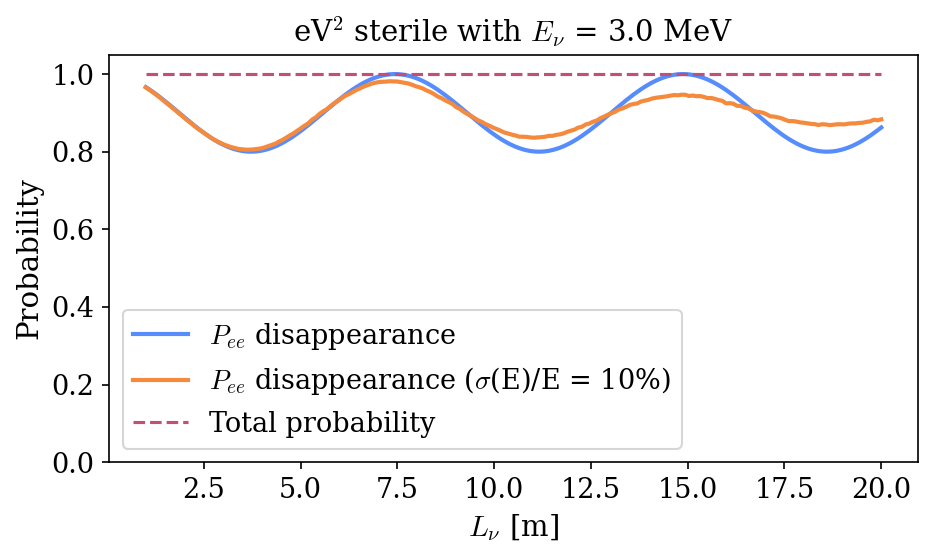

In [4]:
plt.figure(figsize=(6.5, 4.0), dpi=150)
plt.plot(L_list * 1000, P_ee_2f, label=r"$P_{e e}$ disappearance", lw=2)
plt.plot(
    L_list * 1000,
    P_ee_2f_damped,
    label=fr"$P_{{e e}}$ disappearance ($\sigma$(E)/E = {E_res * 100:.0f}%)",
    lw=2,
)
plt.plot(L_list * 1000, np.ones_like(L_list), "--", label="Total probability", lw=1.5)
plt.xlabel(r"$L_\nu$ [m]")
plt.ylabel("Probability")
plt.title(fr"eV$^2$ sterile with $E_\nu$ = {E_fixed * 1000:.1f} MeV")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()


## 2. Reproduction of `faser_sterile.py`

The original script uses an older `Oscillator` construction path. Here we reproduce the same idea with the current API: a 4-flavor vacuum model, muon-flavor survival, and an energy smearing that scales like `sqrt(E)`.

In [5]:
n_bins_E = 100
n_samples_faser = 1000
fixed_L_faser = 0.2
dm2_sterile_faser = 1000.0
E_GeV_faser = np.logspace(2, 4, n_bins_E)

osc_amplitude_faser = 0.5
angles_4f_faser = {
    (1, 2): np.deg2rad(33.4),
    (1, 3): np.deg2rad(8.6),
    (2, 3): np.deg2rad(49),
    (4, 2): np.arcsin(np.sqrt(osc_amplitude_faser)) / 2,
}
dm2_4f_faser = {(2, 1): 7.42e-5, (3, 2): 0.0024428, (4, 1): dm2_sterile_faser}

h_4f_faser = vacuum.Hamiltonian(
    mixing=Mixing(n_neutrinos=4, mixing_angles=angles_4f_faser, dirac_phases=phases_3f),
    spectrum=Spectrum(n_neutrinos=4, m_lightest=0.0, dm2=dm2_4f_faser),
    antineutrino=False,
)
osc_faser = Oscillator(hamiltonian=h_4f_faser)

def energy_sampler_sqrt(E, n_samples, a=10.0):
    xp = Backend.xp()
    E_safe = xp.maximum(E, xp.asarray(1e-12, dtype=Backend.real_dtype()))
    sigma = a * xp.sqrt(E_safe)
    noise = sigma[:, None] * xp.asarray(
        xp.random.standard_normal((E.shape[0], n_samples)), dtype=Backend.real_dtype()
    )
    out = E[:, None] + noise
    return xp.maximum(out, xp.asarray(1e-12, dtype=Backend.real_dtype()))

P_mumu_faser = osc_faser.probability_sampled(
    L_km=fixed_L_faser,
    E_GeV=E_GeV_faser,
    flavor_emit=flavors.muon,
    flavor_det=flavors.muon,
    n_samples=n_samples_faser,
    E_sample_fct=energy_sampler_sqrt,
)

print(P_mumu_faser)


[0.76293939 0.77870516 0.77957183 0.78068409 0.80024093 0.78809791
 0.79282239 0.79767263 0.8005404  0.81492716 0.80935882 0.81969616
 0.81582335 0.81682431 0.82370918 0.83181428 0.82729313 0.8315707
 0.83898492 0.84909068 0.85759199 0.855927   0.86343317 0.85915971
 0.87003904 0.8827273  0.88712179 0.88551284 0.89190793 0.89588245
 0.90397533 0.90463489 0.9207577  0.91847453 0.92810461 0.92923398
 0.93537048 0.93831188 0.94574188 0.9459235  0.95109101 0.95336953
 0.95612258 0.96389657 0.96618555 0.97019235 0.97299288 0.97565246
 0.97713385 0.97907013 0.98020778 0.98408278 0.9840933  0.98682993
 0.98740869 0.98896742 0.98980719 0.99149022 0.99242771 0.99291585
 0.99369265 0.99412776 0.99483002 0.99553815 0.99585535 0.99637822
 0.99649049 0.99693512 0.99723019 0.99754348 0.99771078 0.99802942
 0.99812899 0.99832061 0.99853898 0.99867496 0.99878999 0.9988899
 0.99898357 0.99910046 0.9991674  0.9992372  0.9993139  0.99937648
 0.9994355  0.99948375 0.99953929 0.99957454 0.99961153 0.999649

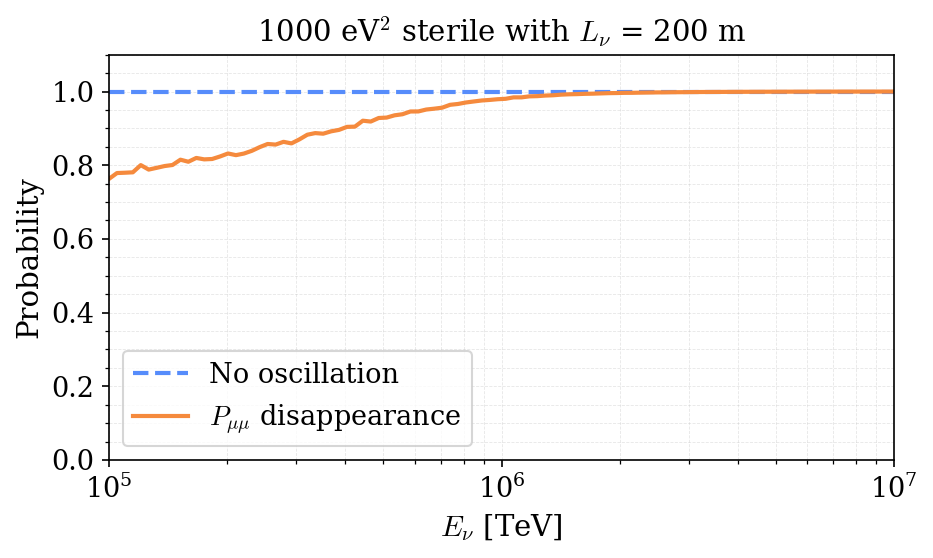

In [6]:
plt.figure(figsize=(6.5, 4.0), dpi=150)
plt.plot(E_GeV_faser * 1000, np.ones_like(E_GeV_faser), "--", label="No oscillation", lw=2)
plt.plot(E_GeV_faser * 1000, P_mumu_faser, label=r"$P_{\mu\mu}$ disappearance", lw=2)
plt.xlabel(r"$E_\nu$ [TeV]")
plt.ylabel("Probability")
plt.title(fr"{dm2_sterile_faser:.0f} eV$^2$ sterile with $L_\nu$ = {fixed_L_faser * 1000:.0f} m")
plt.xscale("log")
plt.xlim(left=E_GeV_faser[0] * 1000, right=E_GeV_faser[-1] * 1000)
plt.ylim(0, 1.1)
plt.legend()
plt.grid(True, which="both", alpha=0.3, lw=0.4, ls="--")
plt.minorticks_on()
plt.tight_layout()
plt.show()


## 3. Reproduction of `sterile_raa_plot.py`

This section compares a 4-flavor sterile-electron survival probability against the standard 3-flavor case, including Gaussian energy smearing.

In [7]:
n_bins_L_sterile = 200
E_res_sterile = 0.05
n_samples_sterile = 5000
fixed_E_sterile = 0.003
L_km_sterile = np.logspace(-2, 2, n_bins_L_sterile)

osc_amplitude_sterile = 0.06
angles_4f_sterile = {
    (1, 2): np.deg2rad(33.4),
    (1, 3): np.deg2rad(8.6),
    (2, 3): np.deg2rad(49),
    (4, 1): np.arcsin(np.sqrt(osc_amplitude_sterile)) / 2,
}
dm2_4f_sterile = {(2, 1): 7.42e-5, (3, 2): 0.0024428, (4, 1): 1.0}

h_4f_sterile = vacuum.Hamiltonian(
    mixing=Mixing(n_neutrinos=4, mixing_angles=angles_4f_sterile, dirac_phases=phases_3f),
    spectrum=Spectrum(n_neutrinos=4, dm2=dm2_4f_sterile),
    antineutrino=False,
)
osc_sterile = Oscillator(hamiltonian=h_4f_sterile)

def gaussian_E_sampler_sterile(E, n_samples, sigma_rel=E_res_sterile):
    xp = Backend.xp()
    noise = sigma_rel * xp.abs(E)[:, None] * xp.asarray(
        xp.random.standard_normal((E.shape[0], n_samples)), dtype=Backend.real_dtype()
    )
    out = E[:, None] + noise
    return xp.maximum(out, xp.asarray(1e-12, dtype=Backend.real_dtype()))

t0 = time.perf_counter()
P_ee_sterile = osc_sterile.probability_sampled(
    L_km=L_km_sterile,
    E_GeV=fixed_E_sterile,
    flavor_emit=flavors.electron,
    flavor_det=flavors.electron,
    n_samples=n_samples_sterile,
    E_sample_fct=gaussian_E_sampler_sterile,
)
t1 = time.perf_counter()
print(f"Computation time: {t1 - t0:.3f} s")

h_3f_sterile_ref = vacuum.Hamiltonian(
    mixing=Mixing(n_neutrinos=3, mixing_angles=angles_3f, dirac_phases=phases_3f),
    spectrum=Spectrum(n_neutrinos=3, dm2=dm2_3f),
    antineutrino=False,
)
osc_sterile.hamiltonian = h_3f_sterile_ref

P_ee_3f_ref = osc_sterile.probability_sampled(
    L_km=L_km_sterile,
    E_GeV=fixed_E_sterile,
    flavor_emit=flavors.electron,
    flavor_det=flavors.electron,
    n_samples=n_samples_sterile,
    E_sample_fct=gaussian_E_sampler_sterile,
)


Computation time: 0.256 s


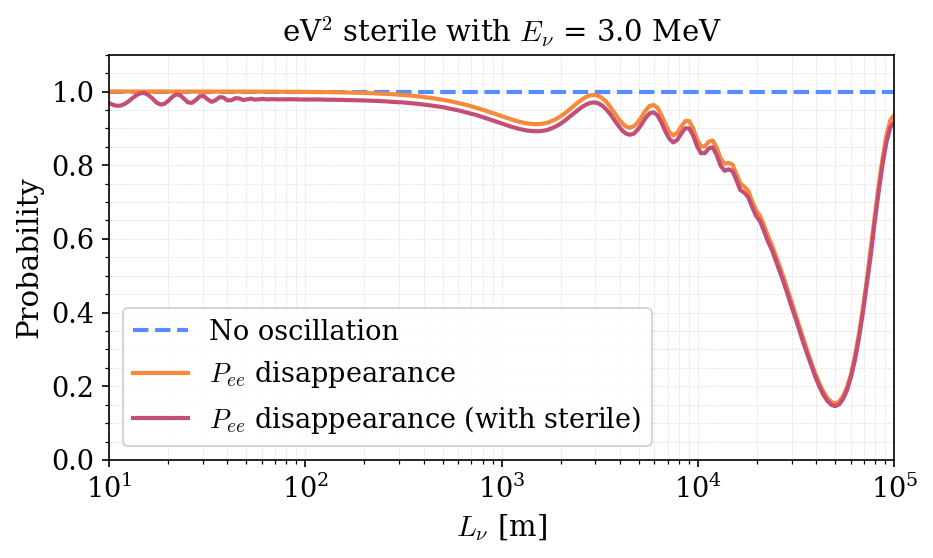

In [8]:
plt.figure(figsize=(6.5, 4.0), dpi=150)
plt.plot(L_km_sterile * 1000, np.ones_like(L_km_sterile), "--", label="No oscillation", lw=2)
plt.plot(L_km_sterile * 1000, P_ee_3f_ref, label=r"$P_{e e}$ disappearance", lw=2)
plt.plot(L_km_sterile * 1000, P_ee_sterile, label=r"$P_{e e}$ disappearance (with sterile)", lw=2)
plt.xlabel(r"$L_\nu$ [m]")
plt.ylabel("Probability")
plt.title(fr"eV$^2$ sterile with $E_\nu$ = {fixed_E_sterile * 1000:.1f} MeV")
plt.xscale("log")
plt.xlim(left=L_km_sterile[0] * 1000, right=L_km_sterile[-1] * 1000)
plt.ylim(0, 1.1)
plt.legend()
plt.grid(True, which="both", alpha=0.3, lw=0.4, ls="--")
plt.minorticks_on()
plt.tight_layout()
plt.show()


## 4. Reproduction of `juno.py`

This section builds a reactor antineutrino spectrum at the JUNO baseline, including an IBD weighting and energy smearing, and compares normal ordering with inverted ordering.

In [9]:
resolution_at_1MeV = 0.03
n_Enu = 1000
n_samples_juno = 10000

E_MeV = np.linspace(1.8, 9.5, n_Enu)
E_GeV_juno = E_MeV * 1e-3

flux_model = ReactorSpectrum(FissionFractions(0.55, 0.30, 0.07, 0.08))
ibd = IBDCrossSection()
flux = flux_model.build_flux(E_MeV)
det_flux = ibd.weighted_flux(E_MeV, flux)

h_juno = vacuum.Hamiltonian(
    mixing=Mixing(n_neutrinos=3, mixing_angles=angles_3f, dirac_phases=phases_3f),
    spectrum=Spectrum(n_neutrinos=3, m_lightest=0, dm2=dm2_3f),
    antineutrino=True,
)
osc_juno = Oscillator(hamiltonian=h_juno)

def smear_energy_juno(E_nu_true_GeV, n_samples, resolution_at_1MeV=resolution_at_1MeV):
    xp = Backend.xp()
    E_nu_true = xp.asarray(E_nu_true_GeV) * 1e3
    sigma_E = resolution_at_1MeV * xp.sqrt(xp.clip(E_nu_true, 1e-6, None))
    E_nu_rec = E_nu_true[:, None] + sigma_E[:, None] * xp.asarray(
        xp.random.standard_normal((E_nu_true.shape[0], n_samples)), dtype=Backend.real_dtype()
    )
    E_nu_rec = xp.clip(E_nu_rec, 0.0, None)
    return E_nu_rec * 1e-3

Pee_NO = osc_juno.probability_sampled(
    L_km=52.5,
    E_GeV=E_GeV_juno,
    flavor_emit=flavors.electron,
    flavor_det=flavors.electron,
    n_samples=n_samples_juno,
    E_sample_fct=smear_energy_juno,
)
spectrum_NO = det_flux * Pee_NO

osc_juno.hamiltonian.spectrum.set_dm2({(3, 2): -dm2_3f[(3, 2)]})
Pee_IO = osc_juno.probability_sampled(
    L_km=52.5,
    E_GeV=E_GeV_juno,
    flavor_emit=flavors.electron,
    flavor_det=flavors.electron,
    n_samples=n_samples_juno,
    E_sample_fct=smear_energy_juno,
)
spectrum_IO = det_flux * Pee_IO


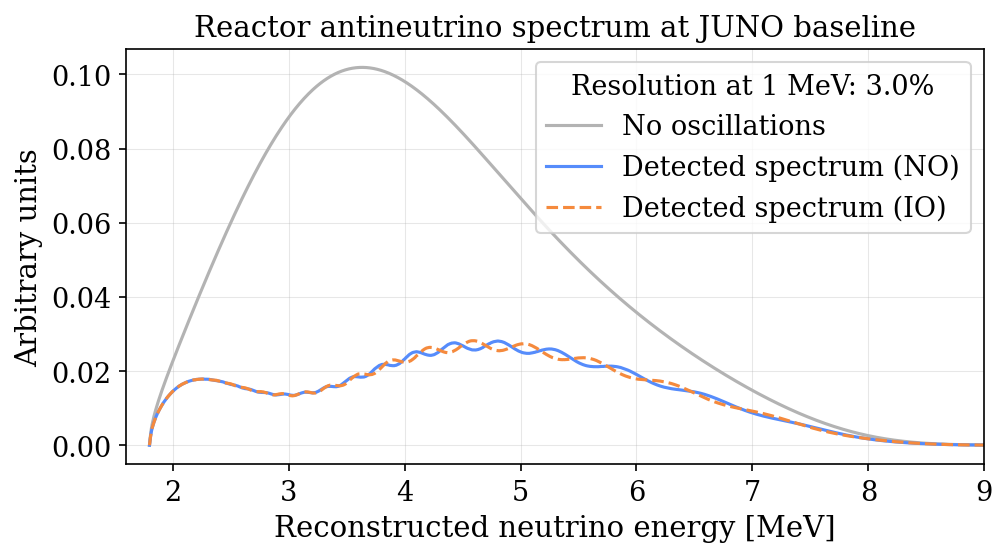

In [10]:
plt.figure(figsize=(7, 4), dpi=150)
plt.plot(E_MeV, det_flux, color="0.7", lw=1.5, label="No oscillations")
plt.plot(E_MeV, spectrum_NO, label="Detected spectrum (NO)")
plt.plot(E_MeV, spectrum_IO, "--", label="Detected spectrum (IO)")
plt.xlabel("Reconstructed neutrino energy [MeV]")
plt.ylabel("Arbitrary units")
plt.title("Reactor antineutrino spectrum at JUNO baseline")
plt.grid(True, alpha=0.3)
plt.xlim(left=1.6, right=9.0)
plt.legend(
    loc="best",
    title=fr"Resolution at 1 MeV: {resolution_at_1MeV * 100:.1f}%",
    title_fontsize=13,
)
plt.tight_layout()
plt.show()
